<a href="https://colab.research.google.com/github/ArkoAhmed731/AI-projects/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Neural Network

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - loss: 0.0804
Epoch 2/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0061
Epoch 3/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - loss: 0.0062
Epoch 4/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0056
Epoch 5/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - loss: 0.0052
Epoch 6/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0048
Epoch 7/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0041
Epoch 8/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0045
Epoch 9/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - loss: 0.0043
Epoch 10/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0049
Epoch 11/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - loss: 0.0036
Epoch 12/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0038
Epoch 13/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - loss: 0.0038
Epoch 14/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0048
Epoch 15/90
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - l

<function matplotlib.pyplot.show(close=None, block=None)>

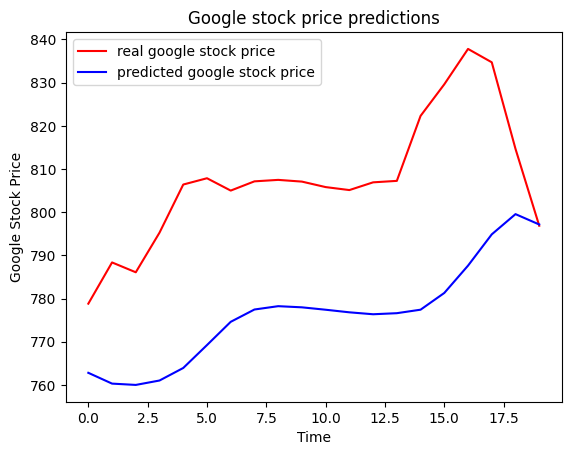

In [1]:
##RNN
#Data Preprocessing
#Part 1- Importing The Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Importing the training set

dataset_train =  pd.read_csv('/content/Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[:, 1:2].values

#Feature Scaling

from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range= (0,1))
training_set_scaled = sc.fit_transform(training_set)

#Creating a data structure with 60 timesteps and 1 output

x_train = []
y_train = []
for i in range (60, 1258):
    x_train.append(training_set_scaled[i-  60:i, 0])
    y_train.append(training_set_scaled[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

#Reshaping

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

#Part 2 Building the RNN

#Importing the Keras Libraries and Packages

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

#Initialising the RNN

regressor = Sequential()

#Adding the first LSTM Layer and some Dropout Regularisation

regressor.add(LSTM(units = 50, return_sequences = True, input_shape =(x_train.shape[1], 1)))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units = 1))

#Compiling the RNN

regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

#Fitting the RNN to the training set

regressor.fit(x_train, y_train, epochs = 90, batch_size = 32)

#Part 3 Making Predictions and visualising
#Getting the real stock price of 2017

dataset_test =  pd.read_csv('/content/Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

#Getting the predicted stock price of 2017

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total)-len(dataset_test)-60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
x_test = []
for i in range (60, 80):
    x_test.append(inputs[i - 60:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

#Visualising the results

plt.plot(real_stock_price, color = 'red', label = 'real google stock price')
plt.plot(predicted_stock_price, color = 'blue', label = 'predicted google stock price')
plt.title('Google stock price predictions')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show